n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      150 |      4 |  0.000000E+00 |  7.008400E+01 |             - |             -
     2 |      300 |     11 |  0.000000E+00 |  1.788688E+01 |  0.6129848229 |         ideal
     3 |      450 |     19 |  0.000000E+00 |  3.4662239495 |  0.0757880261 |         ideal
     4 |      600 |     20 |  0.000000E+00 |  0.000000E+00 |  0.0508369223 |         ideal
     5 |      750 |     26 |  0.000000E+00 |  0.000000E+00 |  0.0865262003 |         ideal
     6 |      900 |     32 |  0.000000E+00 |  0.000000E+00 |  0.0381370344 |             f
     7 |     1050 |     47 |  0.000000E+00 |  0.000000E+00 |  0.0067996971 |         ideal
     8 |     1200 |     54 |  0.000000E+00 |  0.000000E+00 |  0.0030846977 |         nadir
     9 |     1350 |     71 |  0.000000E+00 |  0.000000E+00 |  0.0109232734 |         ideal
    10 |     1500 |    104 |  0.000000E+00 |  0.000000E+00 |  0.0307084616 |         ideal

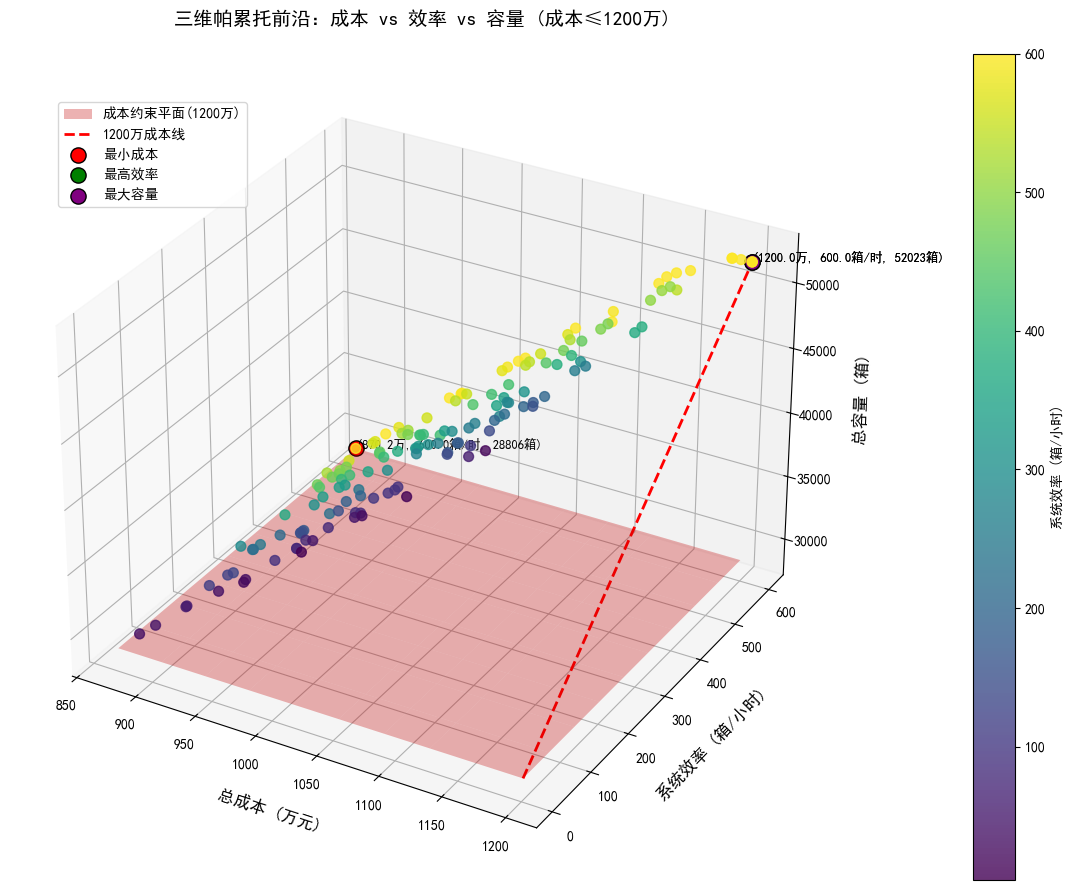

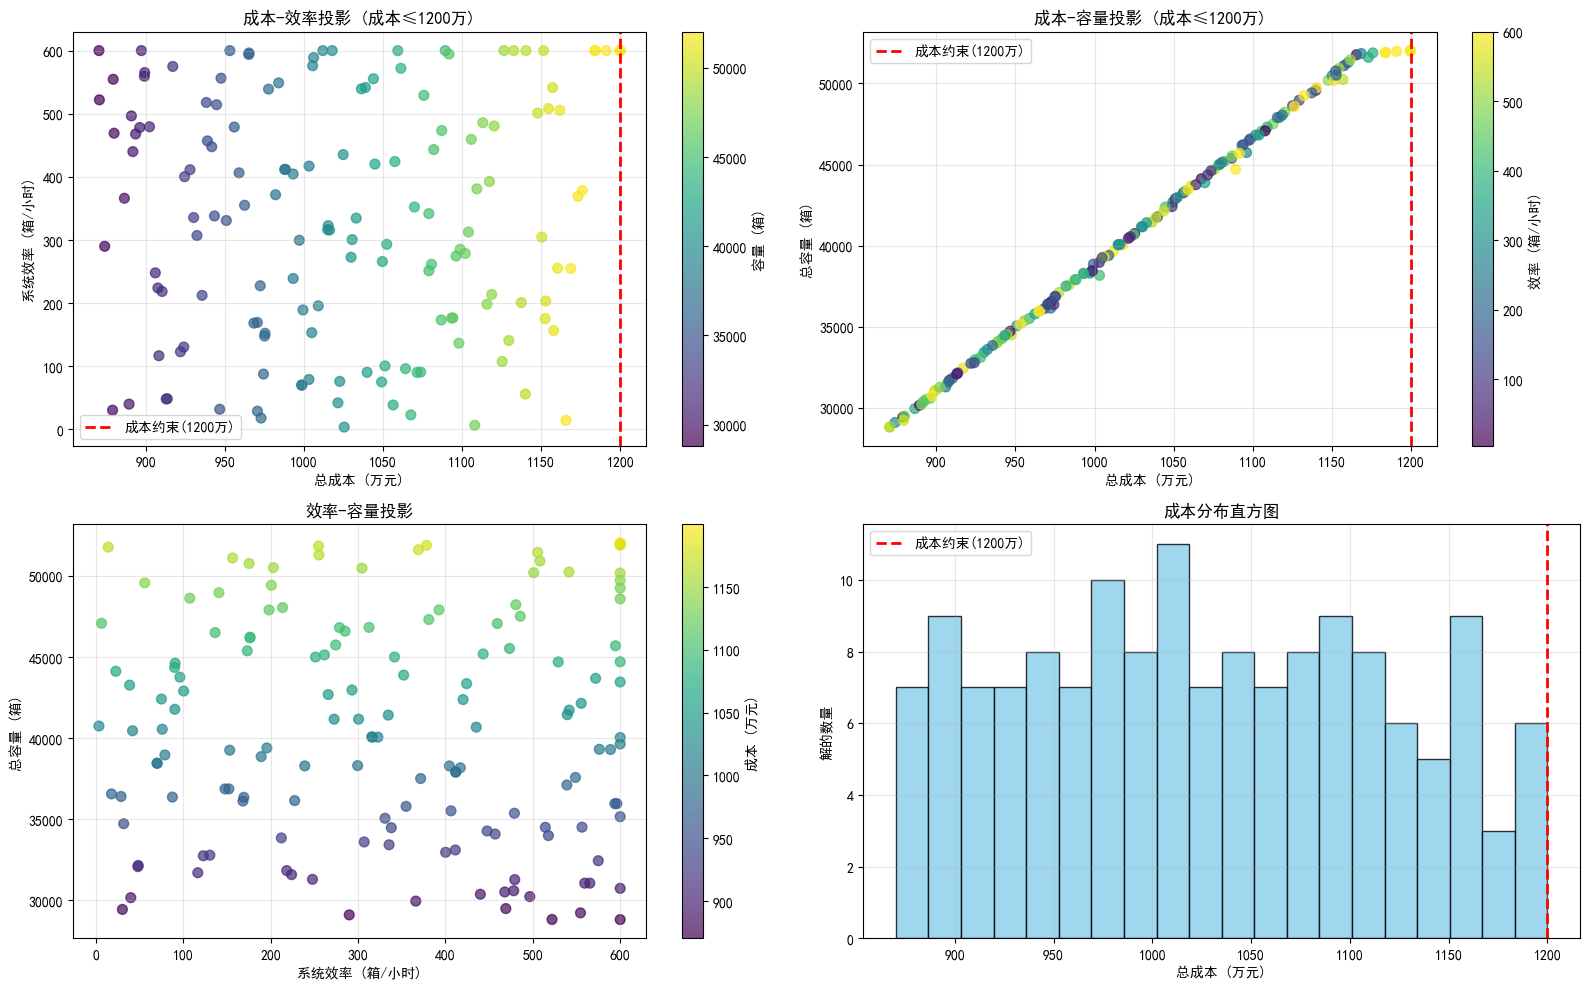


帕累托解集示例（成本≤1000万）：
解1: N_arm=29.999999999191445, N_amr=90.01244283922048, N_old=6.79195606270559, N_columns=59.99999999838289, η_new=0.00 | Cost=1200.0万, Eff=600.0箱/小时, Cap=52023箱
解2: N_arm=23.577108702009145, N_amr=71.69273210685972, N_old=0.006992521503613493, N_columns=47.15421740401829, η_new=0.00 | Cost=1025.4万, Eff=3.7箱/小时, Cap=40741箱
解3: N_arm=16.6704002192828, N_amr=50.0680010851381, N_old=3.978732438826224e-05, N_columns=33.3408004385656, η_new=0.08 | Cost=870.2万, Eff=600.0箱/小时, Cap=28806箱
解4: N_arm=29.999999999191445, N_amr=90.01244283922048, N_old=6.79195606270559, N_columns=59.99999999838289, η_new=0.00 | Cost=1200.0万, Eff=600.0箱/小时, Cap=52023箱
解5: N_arm=28.138791248164505, N_amr=84.72481425607741, N_old=0.006043988966247751, N_columns=56.27758249632901, η_new=0.01 | Cost=1125.3万, Eff=107.6箱/小时, Cap=48624箱
解6: N_arm=27.493546035807455, N_amr=83.61672013260295, N_old=0.0949838358278337, N_columns=54.98709207161491, η_new=0.04 | Cost=1113.1万, Eff=485.7箱/小时, Cap=47511箱
解7: N_

In [14]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ========================== 外部参数配置 ==========================
# 设备成本参数
C_arm = 15    # 大机器人单价（万元/台）
C_amr = 2     # 小机器人单价（万元/台）
C_old_mod = 5 # 旧机器人改造单价（万元/台）
C_rack = 0.2  # 单列货架成本（万元/列）
C_land = 0.1  # 场地成本（万元/㎡）
A_total = 5000 # 仓库总面积（㎡）
k = 100       # 单列货架占地面积（㎡/列）
MAX_COST = 1200  # 成本上限约束（万元）

# 效率参数
alpha = 60    # 旧机器人单位处理量（箱/小时）
beta = 0.2    # 面积衰减系数
v_vertical = 2   # 大机器人垂直速度（m/s）
H_avg = 15    # 平均存储高度（m）
mu = 1      # 操作效率系数
v_horizontal = 3 # 小机器人水平速度（m/s）
D_avg = 50   # 缓存区到工作站平均距离（m）
TaskRate = 200  # 单位时间料箱处理需求（箱/小时）
gamma = 0.1   # 缓存阻塞惩罚系数
manual_time_per_box = 6 / 3600  # 人工操作时间（10秒转换为小时）

# 决策变量范围
arm_range = [1, 30]     # N_arm范围
amr_range = [1, 100]     # N_amr范围
old_range = [0, 50]     # N_old范围
eta_range = [0.0, 1.0]  # η_new范围

# ========================== 定义优化问题 ==========================
class WarehouseProblem(ElementwiseProblem):
    def __init__(self):
        # 决策变量定义：4个变量（3个整数+1个连续）
        super().__init__(
            n_var=4,  # 减少为4个变量
            n_obj=3,  # 三个目标：成本、效率、容量
            n_ieq_constr=4,  # 四个不等式约束
            xl=np.array([arm_range[0], amr_range[0], old_range[0], eta_range[0]]),
            xu=np.array([arm_range[1], amr_range[1], old_range[1], eta_range[1]]),
            vtype=[int, int, int, float]  # 变量类型
        )
    
    def _evaluate(self, x, out, *args, **kwargs):
        # 解析决策变量
        N_arm, N_amr, N_old, eta_new = x
        N_columns = 6 * N_arm  # 货架数量为大机器人数量的两倍
        eta_old = 1 - eta_new
        
        # ---- 约束条件计算 ----
        g1 = 3 * N_arm - N_amr  # 要求：N_amr >= 3*N_arm → g1 <= 0
        A_new = k * N_columns
        A_old = A_total - A_new
        g2 = A_new + A_old - A_total  # 要求：A_new + A_old <= A_total → g2 <= 0
        g3 = TaskRate - 2 * N_columns  # 要求：TaskRate <= 2*N_columns → g3 <= 0
        
        # ---- 目标1：成本计算（最小化） ----
        cost = (
            C_arm * N_arm + 
            C_amr * N_amr +
            C_old_mod * N_old +
            C_rack * N_columns +
            C_land * A_total
        )
        
        # ---- 新增成本约束 ----
        g4 = cost - MAX_COST  # 成本不能超过MAX_COST
        
        # ---- 目标2：效率计算（最大化） ----
        # 旧系统效率
        OldSysEff = N_old * alpha * (1 - beta * A_old / A_total)
        
        # 新系统效率
        ArmEff = N_arm * (v_vertical / H_avg) * mu * 3600  # 转换为箱/小时
        AmrEff = N_amr * (v_horizontal / D_avg) * (A_new / A_total) * 3600  # 转换为箱/小时
        CacheBlockRate = max(0, (TaskRate - 2 * N_columns) / (2 * N_columns))
        NewSysEff = min(ArmEff, AmrEff) * (1 - gamma * CacheBlockRate)
        
        # 综合效率（加权和）
        efficiency = eta_new * NewSysEff + eta_old * OldSysEff
        
        # 考虑人工操作时间限制
        max_manual_capacity = 1 / manual_time_per_box  # 人工最大处理能力（箱/小时）
        efficiency = min(efficiency, max_manual_capacity)
        
        # ---- 目标3：总容量计算（最大化） ----
        capacity = 288 * N_columns + 27 * N_old
        
        # ---- 输出结果 ----
        out["F"] = [cost, -efficiency, -capacity]  # 效率与容量取负
        out["G"] = [g1, g2, g3, g4]  # 包含四个约束

# ========================== 优化执行 ==========================
problem = WarehouseProblem()

# 配置NSGA-II算法
algorithm = NSGA2(
    pop_size=150,
    sampling=IntegerRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 300)

# 执行优化
res = minimize(
    problem,
    algorithm,
    termination,
    seed=1,
    verbose=True
)

# ========================== 结果分析与可视化 ==========================
# 提取三目标结果并转换回正值
F = res.F
F[:, 1] = -F[:, 1]  # 效率转回正值
F[:, 2] = -F[:, 2]  # 容量转回正值

# 绘制3D帕累托前沿
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# 绘制帕累托解集
sc = ax.scatter(F[:, 0], F[:, 1], F[:, 2], c=F[:, 1], cmap='viridis', 
                marker='o', s=50, alpha=0.8, depthshade=True)

# 添加成本约束平面
xx, yy = np.meshgrid(np.linspace(min(F[:, 0]), max(F[:, 0]), 10), 
                     np.linspace(min(F[:, 1]), max(F[:, 1]), 10))
zz = np.zeros_like(xx) + min(F[:, 2])
ax.plot_surface(xx, yy, zz, alpha=0.3, color='red', label=f'成本约束平面({MAX_COST}万)')

# 添加平面上的成本线
cost_line = np.ones(10) * MAX_COST
y_line = np.linspace(min(F[:, 1]), max(F[:, 1]), 10)
z_line = np.linspace(min(F[:, 2]), max(F[:, 2]), 10)
ax.plot(cost_line, y_line, z_line, 'r--', linewidth=2, label=f'{MAX_COST}万成本线')

# 设置坐标轴标签
ax.set_xlabel('总成本 (万元)', fontsize=12, labelpad=10)
ax.set_ylabel('系统效率 (箱/小时)', fontsize=12, labelpad=10)
ax.set_zlabel('总容量 (箱)', fontsize=12, labelpad=10)
plt.title(f"三维帕累托前沿：成本 vs 效率 vs 容量 (成本≤{MAX_COST}万)", fontsize=14, pad=20)
fig.colorbar(sc, ax=ax, label='系统效率 (箱/小时)', pad=0.1)

# 标注典型解
def annotate_point(idx, color, label):
    ax.scatter(F[idx, 0], F[idx, 1], F[idx, 2], s=120, c=color, edgecolors='k', label=label)
    ax.text(F[idx, 0], F[idx, 1], F[idx, 2], 
            f'({F[idx, 0]:.1f}万, {F[idx, 1]:.1f}箱/时, {F[idx, 2]:.0f}箱)', 
            fontsize=9, color='k')

idx_min_cost = np.argmin(F[:, 0])
idx_max_eff = np.argmax(F[:, 1])
idx_max_cap = np.argmax(F[:, 2])

annotate_point(idx_min_cost, 'red', '最小成本')
annotate_point(idx_max_eff, 'green', '最高效率')
annotate_point(idx_max_cap, 'purple', '最大容量')

plt.legend(loc='upper left', bbox_to_anchor=(0.05, 0.95))
plt.tight_layout()
plt.savefig('pareto_front_3d_constrained.png', dpi=300, bbox_inches='tight')
plt.show()

# 绘制2D投影图
plt.figure(figsize=(16, 10))

# 成本-效率投影
plt.subplot(2, 2, 1)
plt.scatter(F[:, 0], F[:, 1], c=F[:, 2], cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='容量 (箱)')
plt.axvline(x=MAX_COST, color='r', linestyle='--', linewidth=2, label=f'成本约束({MAX_COST}万)')
plt.xlabel('总成本 (万元)')
plt.ylabel('系统效率 (箱/小时)')
plt.title(f'成本-效率投影 (成本≤{MAX_COST}万)')
plt.grid(True, alpha=0.3)
plt.legend()

# 成本-容量投影
plt.subplot(2, 2, 2)
plt.scatter(F[:, 0], F[:, 2], c=F[:, 1], cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='效率 (箱/小时)')
plt.axvline(x=MAX_COST, color='r', linestyle='--', linewidth=2, label=f'成本约束({MAX_COST}万)')
plt.xlabel('总成本 (万元)')
plt.ylabel('总容量 (箱)')
plt.title(f'成本-容量投影 (成本≤{MAX_COST}万)')
plt.grid(True, alpha=0.3)
plt.legend()

# 效率-容量投影
plt.subplot(2, 2, 3)
plt.scatter(F[:, 1], F[:, 2], c=F[:, 0], cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='成本 (万元)')
plt.xlabel('系统效率 (箱/小时)')
plt.ylabel('总容量 (箱)')
plt.title('效率-容量投影')
plt.grid(True, alpha=0.3)

# 成本分布直方图
plt.subplot(2, 2, 4)
plt.hist(F[:, 0], bins=20, color='skyblue', edgecolor='black', alpha=0.8)
plt.axvline(x=MAX_COST, color='r', linestyle='--', linewidth=2, label=f'成本约束({MAX_COST}万)')
plt.xlabel('总成本 (万元)')
plt.ylabel('解的数量')
plt.title('成本分布直方图')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('pareto_projection_constrained.png', dpi=300, bbox_inches='tight')
plt.show()

# 计算容量-成本比（箱/万元）辅助决策
capacity_cost_ratio = F[:, 2] / F[:, 0]
idx_best_ratio = np.argmax(capacity_cost_ratio)

# 计算效率-成本比（箱/小时/万元）
efficiency_cost_ratio = F[:, 1] / F[:, 0]
idx_best_efficiency_ratio = np.argmax(efficiency_cost_ratio)

# 筛选符合成本约束的解
feasible_mask = F[:, 0] <= MAX_COST
feasible_F = F[feasible_mask]
feasible_pop = [res.pop[i] for i in range(len(res.pop)) if feasible_mask[i]]

# 输出最优解集
print("\n帕累托解集示例（成本≤1000万）：")
for i in range(min(10, len(feasible_pop))):
    X = feasible_pop[i].X
    N_columns = 2 * X[0]  # 计算货架数量
    print(f"解{i+1}: "
          f"N_arm={X[0]}, N_amr={X[1]}, N_old={X[2]}, "
          f"N_columns={N_columns}, η_new={X[3]:.2f} | "
          f"Cost={feasible_F[i,0]:.1f}万, Eff={feasible_F[i,1]:.1f}箱/小时, "
          f"Cap={feasible_F[i,2]:.0f}箱")

# 输出高性价比解
best_ratio_sol = feasible_pop[idx_best_ratio].X
N_columns_ratio = 2 * best_ratio_sol[0]
print(f"\n最佳容量成本比解: "
      f"N_arm={best_ratio_sol[0]}, N_amr={best_ratio_sol[1]}, N_old={best_ratio_sol[2]}, "
      f"N_columns={N_columns_ratio}, η_new={best_ratio_sol[3]:.2f} | "
      f"Cost={feasible_F[idx_best_ratio,0]:.1f}万, "
      f"Cap={feasible_F[idx_best_ratio,2]:.0f}箱, "
      f"Ratio={capacity_cost_ratio[idx_best_ratio]:.2f}箱/万元")

# 输出高效率成本比解
best_efficiency_ratio_sol = feasible_pop[idx_best_efficiency_ratio].X
N_columns_efficiency = 2 * best_efficiency_ratio_sol[0]
print(f"\n最佳效率成本比解: "
      f"N_arm={best_efficiency_ratio_sol[0]}, N_amr={best_efficiency_ratio_sol[1]}, "
      f"N_old={best_efficiency_ratio_sol[2]}, N_columns={N_columns_efficiency}, "
      f"η_new={best_efficiency_ratio_sol[3]:.2f} | "
      f"Cost={feasible_F[idx_best_efficiency_ratio,0]:.1f}万, "
      f"Eff={feasible_F[idx_best_efficiency_ratio,1]:.1f}箱/小时, "
      f"Ratio={efficiency_cost_ratio[idx_best_efficiency_ratio]:.2f}箱/小时/万元")

# 分析结果范围
print("\n优化结果范围分析（成本≤700万）:")
print(f"成本范围: {min(feasible_F[:, 0]):.1f} - {max(feasible_F[:, 0]):.1f} 万元")
print(f"效率范围: {min(feasible_F[:, 1]):.1f} - {max(feasible_F[:, 1]):.1f} 箱/小时")
print(f"容量范围: {min(feasible_F[:, 2]):.0f} - {max(feasible_F[:, 2]):.0f} 箱")

# 成本约束可行性分析
print(f"\n成本约束分析:")
print(f"总解数量: {len(F)}")
print(f"符合成本约束的解数量: {len(feasible_F)} ({len(feasible_F)/len(F)*100:.1f}%)")
print(f"最高成本解: {max(F[:, 0]):.1f}万元" if len(F) > len(feasible_F) else "所有解均符合成本约束")